---
**Title:** RL 基础 — 从奖励到策略梯度

**Chapter:** 强化学习与大语言模型

**Difficulty:** 入门–中级

**Estimated Time:** 45 分钟

---

## 1. 什么是强化学习（Reinforcement Learning）？

想象你在训练一只狗。你让它坐下：
- **狗坐下了 → 你给它零食** → 狗学会了更多地坐下。
- **狗跳上了桌子 → 没有零食** → 狗学会了避免这样做。

这就是强化学习的核心：**尝试 → 获得反馈 → 调整行为**。

现在把“狗”换成“语言模型”，把“坐下”换成“生成有用的回答”，把“零食”换成“高奖励（Reward）分数”。这就是用于大语言模型的强化学习。

### 大语言模型训练的三个阶段

构建一个好用的大语言模型需要三个阶段：

| 阶段 | 做什么 | 类比 |
|-------|-------------|--------|
| **1. 预训练（Pre-training）** | 在大规模文本上预测下一个 token | 读完图书馆里所有的书 |
| **2. SFT**（监督微调，Supervised Fine-Tuning） | 在人工编写的示例上训练 | 老师给你演示解题过程 |
| **3. RL 对齐（Alignment）** | 针对人类*偏好*进行优化 | 在练习题上做题并按评分标准打分 |

**为什么需要第三阶段？** SFT 教模型*模仿*，但仅靠模仿无法区分“还行”和“很好”。强化学习让模型**自己尝试并从反馈中学习** — 发现人类真正偏好的回答。

### 本 Notebook 的内容

我们将从零开始建立你的 RL 直觉：
1. 核心 RL 词汇（策略、奖励、回合等）
2. 一个你能完全理解的 5 词小型语言模型
3. REINFORCE 算法 — 最简单的策略梯度（Policy Gradient）方法
4. 为什么方差（Variance）是个问题，以及基线（Baseline）如何帮助

**前置知识：** 仅需 PyTorch 基础（张量、`nn.Module`、优化器）。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from collections import Counter
import itertools

from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

from mp_tutorial.viz import draw_training_pipeline, draw_progressive_models
from mp_tutorial.formatting import info_box, comparison_table, formula_breakdown

import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

torch.manual_seed(42)
print("Ready!")

Ready!


### 三阶段训练流水线

下图展示了现代大语言模型的训练方式。本 Notebook 聚焦于**第三阶段** — RL 对齐。

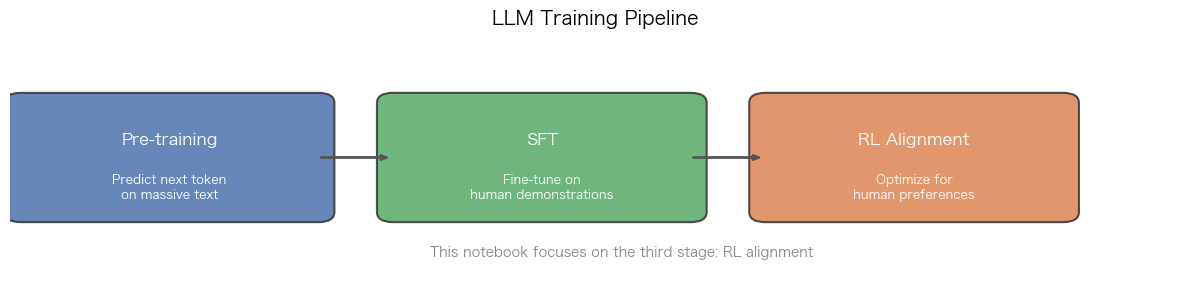

In [2]:
fig, ax = draw_training_pipeline()
plt.show()

## 2. 为什么 SFT 还不够

监督微调（Supervised Fine-Tuning）很强大，但存在根本性的局限：

- **模仿，而非判断。** SFT 教模型复制示范。但它无法区分“还行”的回答和“很好”的回答 — 它对所有训练样本一视同仁。
- **缺乏关于什么重要的信号。** 一个回答可能 95% 都不错，但有一句话具有误导性。SFT 没有办法表达“这部分不好，改掉它”。
- **无法覆盖一切。** 你不可能为每一个可能的问题都写一个人工示范。模型需要能够*泛化*到训练样本之外。

**RL 解决了这个问题：** 我们不再告诉模型该说什么，而是让它**自己尝试并从反馈中学习**。“这个回答得了 0.9 分，那个得了 0.3 分 — 多做第一种。”

这是一种根本不同的学习信号：**对结果的偏好**，而不仅仅是要复制的样本。

## 3. 核心 RL 概念

强化学习有自己的术语体系。以下是每个术语及其在大语言模型中的对应：

| RL 术语 | 一般含义 | 大语言模型中的对应 |
|---------|----------------|----------------|
| **智能体（Agent）** | 决策者 | 语言模型 |
| **环境（Environment）** | 智能体与之交互的世界 | 阅读回答的用户 |
| **动作（Action）** | 智能体做出的选择 | 生成一个 token（或一个完整序列） |
| **状态（State）** | 当前情况 | 到目前为止的对话（提示词 + 已生成的 token） |
| **奖励（Reward）** | 反馈信号（数值） | 人类偏好分数（或奖励模型的输出） |
| **策略（Policy）** | 智能体的策略 — 它如何选择动作 | 模型在 token 上的概率分布 |
| **回合（Episode）** | 一次完整的交互 | 一次完整的生成：提示词 → 完整回答 |

In [3]:
info_box(
    "If you remember one thing from this notebook: "
    "<b>RL = generate → score → learn → repeat.</b> "
    "The model generates a response, gets a reward score, "
    "updates its parameters to make high-scoring responses more likely, "
    "and repeats.",
    title="The RL Loop"
)

## 4. 我们的玩具模型：TinyLM

为了让 RL 概念变得具体，我们将在整个 Notebook 中使用一个*微型*语言模型。

- **词汇表：** 5 个词 — `I`, `love`, `cats`, `hate`, `dogs`
- **序列长度：** 3 个 token（总是以 `I` 开头）
- **所有可能的序列：** 5 × 5 = **25**（因为第一个 token 固定为 `I`，只有位置 2 和 3 变化 — 等等，让我们精确一些：1 × 5 × 5 = 25 个以 `I` 开头的序列，但模型架构允许任意第一个 token，所以总共有 5 × 5 × 5 = **125** 个可能的序列）

> **为什么这么小？** 只有 125 个可能的序列，我们可以精确地可视化模型学到了什么。这里的每个概念都可以直接推广到 GPT 规模的模型 — 只是数字不同。

In [4]:
# ── Our tiny language model ──
VOCAB = ["I", "love", "cats", "hate", "dogs"]
V = len(VOCAB)
SEQ_LEN = 3

def decode(token_ids):
    """Convert token indices to words."""
    return " ".join(VOCAB[t] for t in token_ids.tolist())


class TinyLM(nn.Module):
    """A minimal autoregressive language model.

    Given a sequence of tokens, predicts the next token at each position.
    This is exactly what GPT does — just with 5 words instead of 50,000.
    """
    def __init__(self, vocab_size=V, embed_dim=8, hidden_dim=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """Forward pass (teacher-forced): returns logits at every position."""
        e = self.embed(x)
        h, _ = self.rnn(e)
        return self.head(h)  # (batch, seq_len, vocab_size)

    def log_probs_of(self, sequences):
        """Compute log P(sequence) under the current policy.

        Sums log-probabilities of tokens at positions 1, 2, ..., T-1
        (position 0 is the fixed start token).
        """
        logits = self.forward(sequences)           # (B, T, V)
        dist = torch.distributions.Categorical(logits=logits[:, :-1, :])
        per_token = dist.log_prob(sequences[:, 1:])  # (B, T-1)
        return per_token.sum(dim=1)                   # (B,)

    @torch.no_grad()
    def generate(self, batch_size, seq_len=SEQ_LEN):
        """Generate sequences autoregressively (always starts with 'I')."""
        tokens = [torch.zeros(batch_size, 1, dtype=torch.long)]
        for _ in range(seq_len - 1):
            inp = torch.cat(tokens, dim=1)
            logits = self.forward(inp)[:, -1, :]
            token = torch.distributions.Categorical(logits=logits).sample()
            tokens.append(token.unsqueeze(1))
        return torch.cat(tokens, dim=1)


def reward_fn(sequences):
    """Score sequences: +1 for 'I love cats', penalize 'hate'.

    This is our stand-in for human preferences.
    In real RLHF, a learned reward model replaces this function.
    """
    rewards = []
    for seq in sequences:
        words = [VOCAB[t] for t in seq.tolist()]
        r = 0.0
        if "love" in words and "cats" in words:
            r = 1.0
        elif "love" in words:
            r = 0.3
        if "hate" in words:
            r -= 0.5
        rewards.append(r)
    return torch.tensor(rewards)


# Quick test
model = TinyLM()
seqs = model.generate(8)
print("Sample generations from untrained TinyLM:\n")
for seq in seqs:
    print(f"  {decode(seq):20s}  reward = {reward_fn(seq.unsqueeze(0)).item():+.1f}")

Sample generations from untrained TinyLM:

  I I I                 reward = +0.0
  I cats love           reward = +1.0
  I cats dogs           reward = +0.0
  I cats hate           reward = -0.5
  I love I              reward = +0.3
  I hate dogs           reward = -0.5
  I hate love           reward = -0.2
  I dogs I              reward = +0.0


### “策略（Policy）”长什么样？

我们说**策略**就是模型在 token 上的概率分布。让我们具体看看。给定起始 token `I`，模型认为下一个应该是什么？

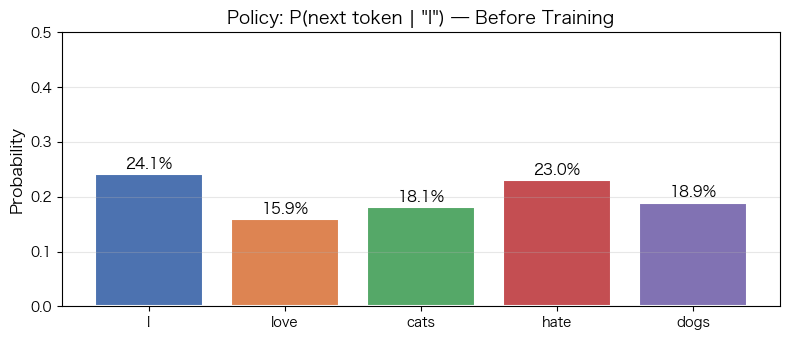

In [5]:
# Show the model's probability distribution for the next token
model = TinyLM()
start = torch.tensor([[0]])  # Token "I" has index 0
logits = model(start)[0, 0, :]
probs = torch.softmax(logits, dim=0)

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
bars = ax.bar(VOCAB, probs.detach().numpy(), color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title('Policy: P(next token | "I") — Before Training', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.5)
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{p:.1%}', ha='center', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

info_box(
    "This is what a <b>policy</b> looks like: a probability distribution over the next token. "
    "Before training, it's roughly uniform — the model has no preference. "
    "RL will reshape this distribution so that good tokens become more likely.",
    title="Policy = Probability Distribution"
)

## 5. 奖励函数（Reward Function）设计

奖励函数是 **RL 的核心** — 它定义了模型应该学习*什么*。

我们的玩具奖励函数：
- **+1.0** — 序列同时包含 "love" 和 "cats"（例如 "I love cats"）
- **+0.3** — 序列包含 "love"（但不包含 "cats"）
- **-0.5** — 序列包含 "hate" 则扣分
- **0.0** — 其他情况

在真实的 RLHF 中，这个手写函数会被一个**奖励模型（Reward Model）** 取代 — 一个在人类偏好数据上训练的神经网络。但原理是一样的：奖励信号告诉策略什么是好的、什么是坏的。

In [6]:
info_box(
    "The reward function defines <b>WHAT</b> the model should learn. "
    "Get it wrong, and the model optimizes the wrong thing — "
    "a phenomenon called <b>reward hacking</b>. For example, a reward model that "
    "favors longer responses will produce a model that rambles.",
    title="Reward Design Matters"
)

### 奖励地图

让我们画出所有可能序列及其奖励的*完整*空间。只有 125 个序列，我们可以看到一切。

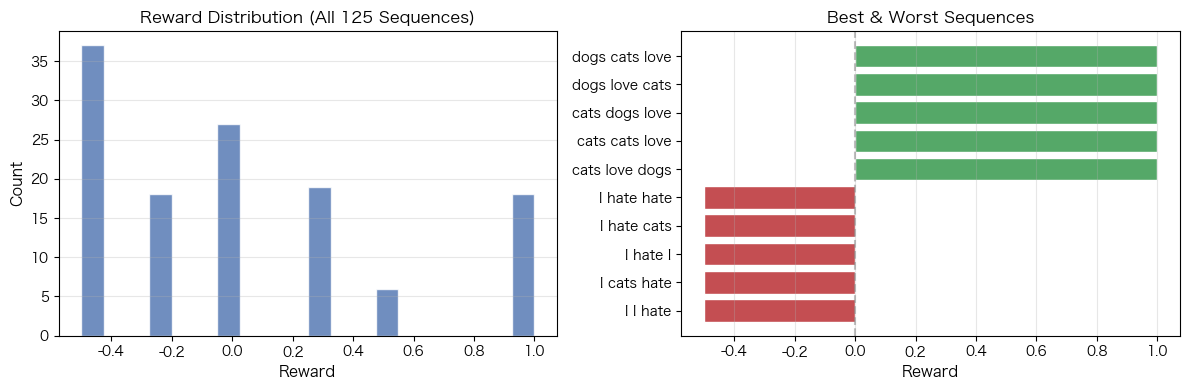

In [7]:
# Generate ALL possible sequences and their rewards
all_seqs = list(itertools.product(range(V), repeat=SEQ_LEN))
all_rewards = []
for seq in all_seqs:
    t = torch.tensor([seq])
    all_rewards.append(reward_fn(t).item())

# Show distribution of rewards
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of rewards
ax1.hist(all_rewards, bins=20, color='#4C72B0', edgecolor='white', alpha=0.8)
ax1.set_xlabel("Reward", fontsize=11)
ax1.set_ylabel("Count", fontsize=11)
ax1.set_title("Reward Distribution (All 125 Sequences)", fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Right: top and bottom sequences
sorted_seqs = sorted(zip(all_rewards, all_seqs), reverse=True)
top5 = sorted_seqs[:5]
bot5 = sorted_seqs[-5:]

y_labels = [" ".join(VOCAB[t] for t in s) for _, s in top5 + bot5]
x_vals = [r for r, _ in top5 + bot5]
colors_bar = ['#55A868'] * 5 + ['#C44E52'] * 5

ax2.barh(range(10), x_vals, color=colors_bar, edgecolor='white')
ax2.set_yticks(range(10))
ax2.set_yticklabels(y_labels, fontsize=10)
ax2.set_xlabel("Reward", fontsize=11)
ax2.set_title("Best & Worst Sequences", fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## 6. 策略梯度（Policy Gradient）：核心思想

以下是用 RL 训练语言模型的根本洞见：

> **提高获得高奖励的序列的概率。
> 降低获得低奖励的序列的概率。**

就是这样。其他一切 — PPO、DPO、GRPO — 都是这个单一思想的改进。

在数学上，**REINFORCE** 算法（Williams, 1992）说：

$$\nabla J(\theta) = \mathbb{E}\left[ R \cdot \nabla \log \pi_\theta(\text{sequence}) \right]$$

让我们逐项分解：

In [8]:
formula_breakdown([
    (
        "\u03c0\u2098(sequence) — the probability the model<br>"
        "assigns to this complete sequence",
        "\u03c0<sub>\u03b8</sub>(a\u2081, a\u2082, \u2026 | s)",
        "probs = model(sequence).softmax(-1)",
    ),
    (
        "log \u03c0\u2098 — take the log (turns products<br>"
        "of probabilities into sums; numerically stable)",
        "log \u03c0<sub>\u03b8</sub> = \u03a3 log P(a\u209c | a\u2081..\u209c\u208b\u2081)",
        "log_probs = model.log_probs_of(sequence)",
    ),
    (
        "R — the reward score for this sequence<br>"
        "(how good was the complete response?)",
        "R(sequence)",
        "reward = reward_fn(sequence)",
    ),
    (
        "R \u00b7 \u2207log \u03c0\u2098 — push the model toward<br>"
        "high-reward sequences (positive R amplifies<br>"
        "the gradient; negative R reverses it)",
        "R \u00b7 \u2207 log \u03c0<sub>\u03b8</sub>",
        "loss = -(reward * log_probs).mean()",
    ),
], title="REINFORCE — Term by Term")

In Plain English,Math,PyTorch
πₘ(sequence) — the probability the modelassigns to this complete sequence,"πθ(a₁, a₂, … | s)",probs = model(sequence).softmax(-1)
log πₘ — take the log (turns productsof probabilities into sums; numerically stable),log πθ = Σ log P(aₜ | a₁..ₜ₋₁),log_probs = model.log_probs_of(sequence)
R — the reward score for this sequence(how good was the complete response?),R(sequence),reward = reward_fn(sequence)
R · ∇log πₘ — push the model towardhigh-reward sequences (positive R amplifiesthe gradient; negative R reverses it),R · ∇ log πθ,loss = -(reward * log_probs).mean()


### 为什么用对数概率（Log Probabilities）？

你可能会想：为什么用*对数*概率而不是原始概率？

两个实际原因：

1. **数值稳定性。** 一个序列的概率是每个 token 概率的*乘积*。对于一个 100 个 token 的序列：$P = p_1 \times p_2 \times \dots \times p_{100}$。即使每个 $p_i = 0.5$，乘积也是 $2^{-100} \approx 10^{-30}$ — 对浮点数来说太小了。取对数将乘积变为求和：$\log P = \log p_1 + \log p_2 + \dots + \log p_{100}$，在数值上完全没问题。

2. **简洁的梯度。** $\log \pi_\theta$ 对 $\theta$ 的梯度有一个特别简洁的形式（在统计学中称为“得分函数”（Score Function））。这就是 REINFORCE 能工作的原因 — $\nabla \log \pi$ 项自然地告诉我们应该往哪个方向调整参数。

In [9]:
info_box(
    "<b>The Score Function Trick:</b> "
    "The identity \u2207 log f(x) = \u2207f(x) / f(x) means we can compute "
    "policy gradients by sampling — no need to enumerate all possible sequences. "
    "This is what makes RL scalable to models with trillions of possible outputs.",
    title="Why This Works at Scale"
)

## 7. REINFORCE 训练

让我们用 REINFORCE 训练 TinyLM。这个算法出奇地简单：

1. 从当前策略**生成**一批序列
2. 用奖励函数给每个序列**打分**
3. **计算**策略梯度：$\text{loss} = -(R \cdot \log \pi_\theta)$
4. 用梯度下降**更新**模型参数
5. **重复**

In [10]:
# ── Train with REINFORCE ──
torch.manual_seed(42)
policy = TinyLM()
optimizer = torch.optim.Adam(policy.parameters(), lr=5e-3)
reward_history = []

for step in range(300):
    seqs = policy.generate(batch_size=64)
    rewards = reward_fn(seqs)

    # REINFORCE with baseline (subtract mean to reduce variance)
    baseline = rewards.mean()
    advantages = rewards - baseline

    log_probs = policy.log_probs_of(seqs)
    loss = -(log_probs * advantages).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_history.append(rewards.mean().item())
    if step % 60 == 0:
        print(f"Step {step:3d}  avg reward = {rewards.mean():.3f}")

print(f"\nFinal avg reward: {reward_history[-1]:.3f}")

Step   0  avg reward = -0.059
Step  60  avg reward = 0.905
Step 120  avg reward = 1.000
Step 180  avg reward = 0.984


Step 240  avg reward = 1.000

Final avg reward: 1.000


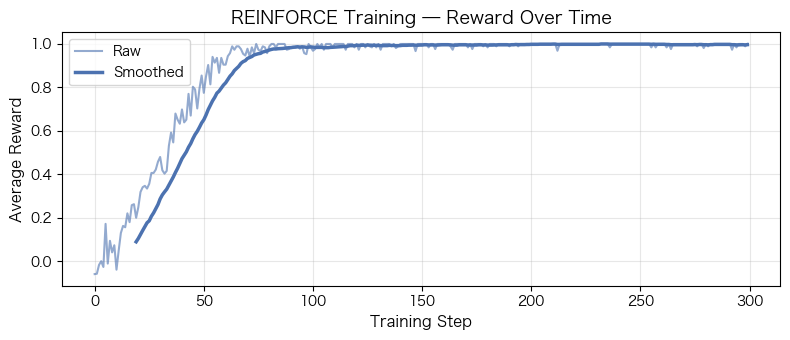

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(reward_history, color="#4C72B0", lw=1.5, alpha=0.6, label="Raw")
# Smoothed curve
window = 20
smoothed = np.convolve(reward_history, np.ones(window)/window, mode="valid")
ax.plot(range(window-1, len(reward_history)), smoothed, color="#4C72B0", lw=2.5, label="Smoothed")
ax.set_xlabel("Training Step", fontsize=11)
ax.set_ylabel("Average Reward", fontsize=11)
ax.set_title("REINFORCE Training — Reward Over Time", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

info_box(
    "REINFORCE works! The model learns to generate higher-reward sequences. "
    "But look at the <b>variance</b> (noise) in the raw curve — the reward bounces "
    "around wildly from step to step. This high variance is a known problem with "
    "vanilla policy gradients.",
    title="Observation"
)

In [12]:
# What did the model learn to generate?
print("Most common sequences after REINFORCE training:\n")
seqs = policy.generate(500)
counts = Counter(decode(s) for s in seqs)
for text, count in counts.most_common(8):
    r = reward_fn(torch.tensor([[VOCAB.index(w) for w in text.split()]])).item()
    print(f"  {text:20s}  freq={count/500:.0%}  reward={r:+.1f}")

Most common sequences after REINFORCE training:

  I cats love           freq=79%  reward=+1.0
  I love cats           freq=20%  reward=+1.0
  I love love           freq=0%  reward=+0.3


### 训练前后的策略对比

让我们看看 REINFORCE 是如何重塑模型概率分布的。

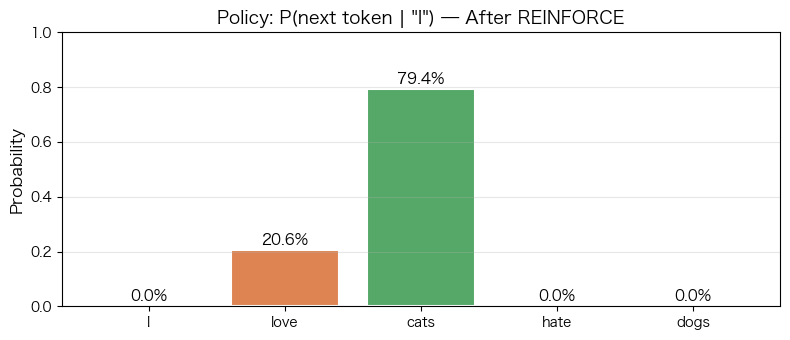

In [13]:
# What does the policy look like now?
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

start = torch.tensor([[0]])  # "I"
logits_after = policy(start)[0, 0, :]
probs_after = torch.softmax(logits_after, dim=0)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(VOCAB, probs_after.detach().numpy(), color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title('Policy: P(next token | "I") — After REINFORCE', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
for bar, p in zip(bars, probs_after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{p:.1%}', ha='center', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

info_box(
    "After training, the model strongly prefers 'love' — exactly the token "
    "that leads to high rewards. Compare this to the roughly uniform distribution "
    "before training. The policy has been <b>shaped by the reward signal</b>.",
    title="Policy After Training"
)

## 8. 方差（Variance）问题

你看到了上面噪杂的训练曲线。让我们用 **5 个不同的随机种子**运行 REINFORCE，使这个问题更加明显。

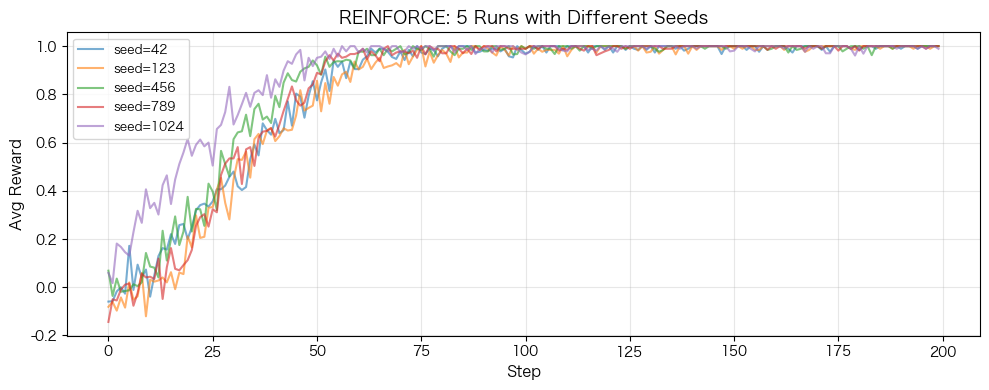

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
for seed in [42, 123, 456, 789, 1024]:
    torch.manual_seed(seed)
    p = TinyLM()
    opt = torch.optim.Adam(p.parameters(), lr=5e-3)
    hist = []
    for step in range(200):
        seqs = p.generate(batch_size=64)
        rewards = reward_fn(seqs)
        baseline = rewards.mean()
        advantages = rewards - baseline
        log_probs = p.log_probs_of(seqs)
        loss = -(log_probs * advantages).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        hist.append(rewards.mean().item())
    ax.plot(hist, alpha=0.6, lw=1.5, label=f'seed={seed}')

ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel("Avg Reward", fontsize=11)
ax.set_title("REINFORCE: 5 Runs with Different Seeds", fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

info_box(
    "Each run converges, but the <b>paths are wildly different</b>. Some converge fast, "
    "others are slow and noisy. This high variance is REINFORCE's Achilles heel. "
    "Next notebook: PPO fixes this with clipping and multiple update steps.",
    title="The Variance Problem"
)

## 9. 基线技巧（Baseline Trick）

在训练循环中我们一直在减去平均奖励（即“基线”）。为什么？

**直觉：** 想象你所有的序列都获得了 0.5 到 1.0 之间的奖励。如果没有基线，*每个*序列都会被增强（所有奖励都是正的）。模型学得很慢，因为没有对比。

有了基线，我们问的是：“这个序列**比平均水平好还是差？**”
- 高于平均 → 正优势（Advantage）→ 增加概率
- 低于平均 → 负优势 → 降低概率

这就像**按曲线评分** — 重要的是相对表现，而非绝对分数。

**从数学上看：** 减去一个常数基线不会改变梯度的期望（这是一个零均值修正），但它**显著降低了方差**。

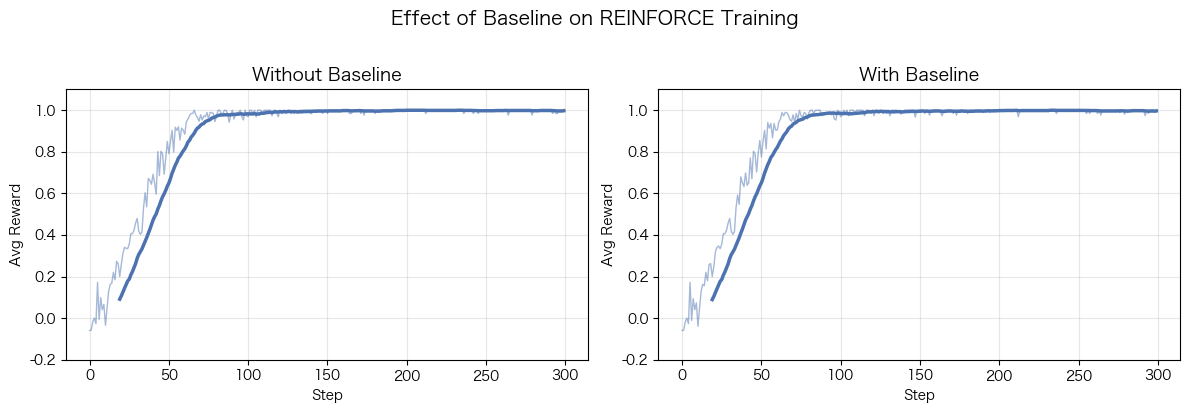

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, use_baseline, title in [(ax1, False, "Without Baseline"), (ax2, True, "With Baseline")]:
    torch.manual_seed(42)
    p = TinyLM()
    opt = torch.optim.Adam(p.parameters(), lr=5e-3)
    hist = []
    for step in range(300):
        seqs = p.generate(batch_size=64)
        rewards = reward_fn(seqs)
        if use_baseline:
            advantages = rewards - rewards.mean()
        else:
            advantages = rewards
        log_probs = p.log_probs_of(seqs)
        loss = -(log_probs * advantages).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        hist.append(rewards.mean().item())

    ax.plot(hist, color='#4C72B0', alpha=0.5, lw=1)
    window = 20
    smoothed = np.convolve(hist, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(hist)), smoothed, color='#4C72B0', lw=2.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Step")
    ax.set_ylabel("Avg Reward")
    ax.set_ylim(-0.2, 1.1)
    ax.grid(alpha=0.3)

plt.suptitle("Effect of Baseline on REINFORCE Training", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 总结

### 关键要点

1. **RL = 生成、打分、学习、重复。** 模型生成回答，获得奖励分数，然后更新参数使高分回答更有可能出现。

2. **策略（Policy）= token 上的概率分布。** 训练前大致均匀；训练后被奖励信号重塑。

3. **REINFORCE** 是最简单的策略梯度：$\text{loss} = -(R \cdot \log \pi_\theta)$。增加高奖励序列的概率，降低低奖励序列的概率。

4. **基线技巧**（减去平均奖励）在不改变梯度期望的情况下降低方差。就像按曲线评分一样。

5. **方差仍然是个问题。** 即使有了基线，REINFORCE 的训练仍然是噪杂的，对随机种子敏感。

In [16]:
info_box(
    "REINFORCE works but is fragile — high variance, no safety net against "
    "destructive updates. In the <b>next notebook</b>, we build PPO step by step: "
    "adding a value model, clipping the policy ratio, and KL penalties to make "
    "training stable and reliable.",
    title="What's Next: PPO (Notebook 01)"
)